<a href="https://colab.research.google.com/github/Rini43/Case-Study-on-Supervised-Learning/blob/main/Assignement_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import time
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim


# Read the Data

In [115]:
# filepath to the .csv file
filepath = '/content/drive/MyDrive/Data/adult_dataset.csv'
df_adult = pd.read_csv(filepath)
df_adult.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [116]:
X = df_adult.drop("income", axis=1)     # Features
y = df_adult["income"]                  # Labels

In [117]:
# Display summary info
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [118]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [119]:
# Checking for the Duplicates

df_adult.duplicated().sum()

np.int64(16)

In [120]:
df_adult.drop_duplicates(inplace=True)

In [121]:
df_adult.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [122]:
df_adult.replace('?', np.nan, inplace=True)

In [123]:
numerical_cols = ['age', 'hours-per-week']

for col in numerical_cols:
    df_adult[col] = df_adult[col].fillna(df_adult[col].median())

In [124]:
# Find all categorical columns
cat_cols = df_adult.select_dtypes(include=['object']).columns

print(cat_cols)
for col in cat_cols:
    df_adult[col] = df_adult[col].fillna(df_adult[col].mode()[0])

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


In [125]:
df_adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# Outlier

<Axes: >

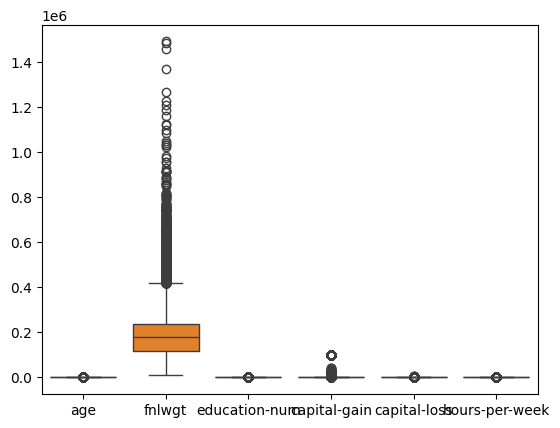

In [126]:
sns.boxplot(df_adult)

# One-Hot Encode Categorical Features


In [127]:
X = pd.get_dummies(X, drop_first=True)

# Label Encoder for Target Variable

In [128]:
# Encode Target Variable

le = LabelEncoder()
y = le.fit_transform(y)


# Scaling & Data Split

In [129]:
# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [130]:
# Use Standard Scale

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (39073, 100)
Testing Shape : (9769, 100)


In [131]:
# Build an ANN

model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(100,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [132]:
# Compile

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [133]:
# Train

start_time = time.perf_counter()
history = model.fit( X_train, y_train, validation_split=0.2,
    epochs=30, batch_size=32, verbose=1)
end_time = time.perf_counter()

print(f"Training time: {end_time - start_time} seconds")

Epoch 1/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 2/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 3/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 4/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 5/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 6/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 7/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 8/30
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5056 - loss: nan - val_accuracy: 0.5080 - val_loss: nan
Epoch 9/30
977/977 ━━━━━

In [134]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5062 - loss: nan
Test Loss : nan
Test Accuracy : 0.5061930418014526


# Pytorch

In [135]:
# Convert every data to tensor

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
y_test_tensor = torch.FloatTensor(y_test.reshape(-1,1))

In [144]:
torch.unique(y_train_tensor)

tensor([0., 1., 2., 3.])

In [138]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(100, 64),   # Input: 30 features, Output: 64 neurons
            nn.ReLU(),
            nn.Linear(64, 32),   # Hidden layer
            nn.ReLU(),
            nn.Linear(32, 16),   # Hidden layer
            nn.ReLU(),
            nn.Linear(16, 1),    # Output layer
            nn.Sigmoid()         # Binary classification
        )

    def forward(self, x):
        return self.network(x)

# Create the model
model = ANN()

In [142]:
criterion = nn.BCEWithLogitsLoss()

In [140]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [143]:
start_time = time.perf_counter()

epochs = 50
for epoch in range(epochs):
  outputs = model(X_train_tensor)
  loss = criterion(outputs, y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if(epoch+1)%10 == 0:
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

end_time = time.perf_counter()

print(f"Training time: {end_time - start_time:.4f} seconds")

Epoch 10, Loss: nan
Epoch 20, Loss: nan
Epoch 30, Loss: nan
Epoch 40, Loss: nan
Epoch 50, Loss: nan
Training time: 2.8566 seconds
